# Comparative Model
LSTM model trained using traditional ML/DL techniques for comparisons with FL models (global / local).

In [ ]:
# Imports
from utils import *
# Parameters
RAND_SEED = 123456
SPLIT_SIZE = 0.2
BATCH_SIZE = 4

# Variables
feature_columns = ['w', 'x', 'y', 'z', 'droll', 'dpitch', 'dyaw', 'ax', 'ay', 'az', 'heart']
# label_column = 'class_encoded'  #'scenario_encoded'
scenario_mapping = {0: 'bed', 1: 'chair', 2: 'clap', 3: 'cloth', 4: 'eat', 5: 'fall1', 6: 'fall2', 
                    7: 'fall3', 8: 'fall4', 9: 'fall5', 10: 'fall6', 11: 'hair', 12: 'shoe', 
                    13: 'stair', 14: 'teeth', 15: 'walk', 16: 'wash', 17: 'write', 18: 'zip'}
class_mapping = {0: 'fall', 1: 'non-fall'}

# Files and folders
DATASET_FOLDER = "."
SAVE_FOLDER = "../results"
EXPORT_FOLDER = "../export"
DATASET_FILE = f"{EXPORT_FOLDER}/dataset.pkl"
TRAIN_DATASET_FILE = f"{EXPORT_FOLDER}/train_dataset.pkl"
VAL_DATASET_FILE = f"{EXPORT_FOLDER}/val_dataset.pkl"
EXPANDED_DATASET_FILE = f"{EXPORT_FOLDER}/dataset_expanded.pkl"
EXPANDED_TRAIN_DATASET_FILE = f"{EXPORT_FOLDER}/train_dataset_expanded.pkl"
EXPANDED_VAL_DATASET_FILE = f"{EXPORT_FOLDER}/val_dataset_expanded.pkl"
COMPARATIVE_MODEL_FILE = f"{EXPORT_FOLDER}/comparative_model.pth"

# Load datasets
df_train = load_pickle(TRAIN_DATASET_FILE)
df_val = load_pickle(VAL_DATASET_FILE)

# Prepare tensors and datasets for training and validation
train_inputs, train_targets = preprocess_dataset(df_train)
val_inputs, val_targets = preprocess_dataset(df_val)
train_dataset = SensorDataset(train_inputs, train_targets)
val_dataset = SensorDataset(val_inputs, val_targets)

# Create DataLoader objects
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

../export/train_dataset.pkl


## Train Model

In [4]:
# Hyperparameters
input_size = len(feature_columns)
num_classes = len(np.unique(train_targets))
hidden_size = 128
num_layers = 2
learning_rate = 0.01
num_epochs = 50

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Initialize model, criterion, and optimizer
model = LSTMModel(input_size, hidden_size, num_layers, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
for epoch in range(num_epochs):
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Export the model
torch.save(model.state_dict(), COMPARATIVE_MODEL_FILE)

Epoch [1/50], Loss: 2.8996
Epoch [2/50], Loss: 2.3198
Epoch [3/50], Loss: 2.1956
Epoch [4/50], Loss: 2.0301
Epoch [5/50], Loss: 1.9961
Epoch [6/50], Loss: 1.5605
Epoch [7/50], Loss: 1.3243
Epoch [8/50], Loss: 1.2880
Epoch [9/50], Loss: 1.5273
Epoch [10/50], Loss: 1.2132
Epoch [11/50], Loss: 0.9216
Epoch [12/50], Loss: 0.8506
Epoch [13/50], Loss: 0.8145
Epoch [14/50], Loss: 0.6430
Epoch [15/50], Loss: 0.8521
Epoch [16/50], Loss: 0.6370
Epoch [17/50], Loss: 0.6746
Epoch [18/50], Loss: 0.8189
Epoch [19/50], Loss: 0.9130
Epoch [20/50], Loss: 0.6689
Epoch [21/50], Loss: 0.8477
Epoch [22/50], Loss: 0.4687
Epoch [23/50], Loss: 0.9504
Epoch [24/50], Loss: 0.7982
Epoch [25/50], Loss: 0.4768
Epoch [26/50], Loss: 0.5723
Epoch [27/50], Loss: 0.6832
Epoch [28/50], Loss: 0.7546
Epoch [29/50], Loss: 0.7637
Epoch [30/50], Loss: 0.6911
Epoch [31/50], Loss: 0.6503
Epoch [32/50], Loss: 0.6098
Epoch [33/50], Loss: 0.3997
Epoch [34/50], Loss: 0.9137
Epoch [35/50], Loss: 0.8048
Epoch [36/50], Loss: 0.7927
E

## Model Performance

In [9]:
# Load previously trained model, if any
model = LSTMModel(input_size, hidden_size, num_layers, num_classes)
model.load_state_dict(torch.load(COMPARATIVE_MODEL_FILE))

<All keys matched successfully>

Accuracy: 0.15873015873015872
Precision: 0.19508692365835223
Recall: 0.15873015873015872
F1 Score: 0.1565633660871756
Matthews Correlation Coefficient (MCC): 0.11060815418058455
Cohen's Kappa: 0.10912486659551768
Hamming Loss: 0.8412698412698413

Confusion Matrix:
 [[1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 2 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 2]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 1 1 0 0]
 [0 0 0 2 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0

/Users/rohanphutke/Desktop/8th Sem Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/rohanphutke/Desktop/8th Sem Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/rohanphutke/Desktop/8th Sem Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

<Figure size 1200x1000 with 0 Axes>

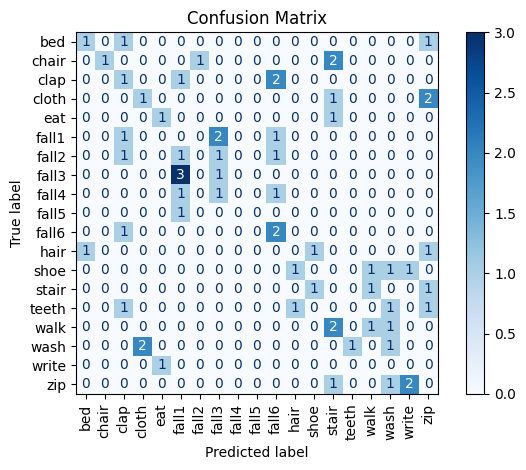

Classification Report:
               precision    recall  f1-score   support

         bed       0.50      0.33      0.40         3
       chair       1.00      0.25      0.40         4
        clap       0.17      0.25      0.20         4
       cloth       0.33      0.25      0.29         4
         eat       0.50      0.50      0.50         2
       fall1       0.00      0.00      0.00         4
       fall2       0.00      0.00      0.00         4
       fall3       0.20      0.25      0.22         4
       fall4       0.00      0.00      0.00         3
       fall5       0.00      0.00      0.00         1
       fall6       0.29      0.67      0.40         3
        hair       0.00      0.00      0.00         3
        shoe       0.00      0.00      0.00         4
       stair       0.00      0.00      0.00         3
       teeth       0.00      0.00      0.00         4
        walk       0.33      0.25      0.29         4
        wash       0.20      0.25      0.22         4
   

{'accuracy': 0.15873015873015872,
 'precision': 0.19508692365835223,
 'recall': 0.15873015873015872,
 'f1': 0.1565633660871756,
 'mcc': 0.11060815418058455,
 'kappa': 0.10912486659551768,
 'hamming_loss_val': 0.8412698412698413,
 'cm': array([[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0

In [11]:
# Evaluation mode
model.eval()

# Lists to store predictions and true labels
all_predictions = []
all_targets = []

# Evaluate on the validation set (assuming you have a separate validation set)
with torch.no_grad():
    for inputs, labels in val_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class indices
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Get model's performance
get_metrics(all_targets, all_predictions, scenario_mapping.values(), print_results=True)